### Imports


In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE


In [223]:
### Ajustes de visualización
sns.set(style="whitegrid")
%matplotlib inline
plt.style.use("bmh")


In [224]:
### Cargamos los datos
df= pd.read_csv("IRIS.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [225]:
df.shape

(150, 5)

In [226]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [227]:
### renombrar columnas
df.rename({'sepal_length': 'sep_l (cm)', 'sepal_width': 'sep_w (cm)', 'petal_length': 'pet_l (cm)', 'petal_width': 'pet_w (cm)', 'species': 'especie'}, axis=1, inplace=True)
df

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm),especie
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [228]:
df.describe()

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [229]:
df["especie"].value_counts()

especie
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [230]:
df.value_counts(["especie"], normalize=True)


especie        
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64

C:\Users\Surface\AppData\Local\Temp\ipykernel_15680\4027095492.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="especie", data=df, palette="pastel")


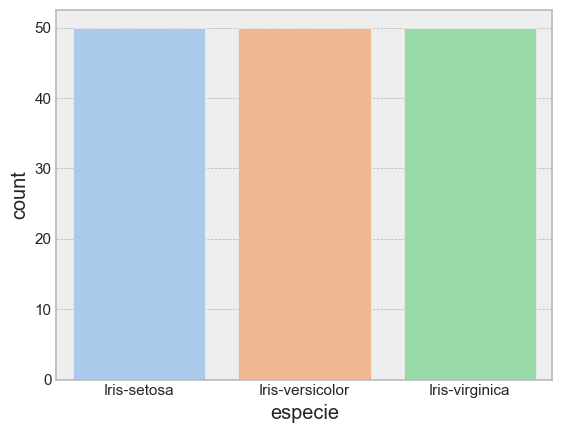

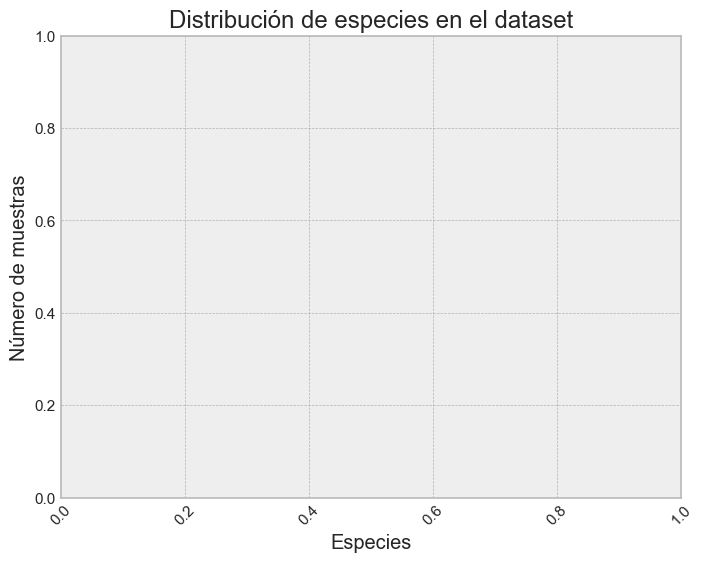

In [231]:
sns.countplot(x="especie", data=df, palette="pastel")
plt.figure(figsize=(8, 6))
plt.title("Distribución de especies en el dataset")
plt.xlabel("Especies")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45)
plt.show()


In [232]:
###Comprobamos si hay valores nulos
df.isnull()


,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm),especie
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [233]:
df.isnull().sum()

sep_l (cm)    0
sep_w (cm)    0
pet_l (cm)    0
pet_w (cm)    0
especie       0
dtype: int64

In [234]:
### no hay valores nulos


###
Analisis Univariante

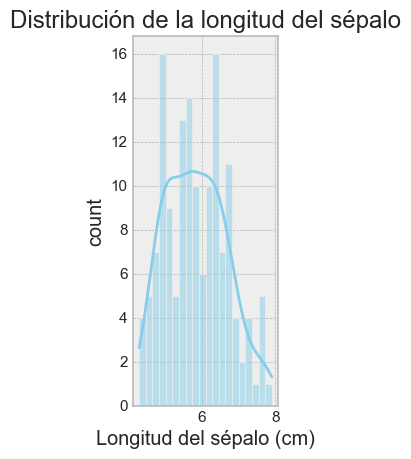

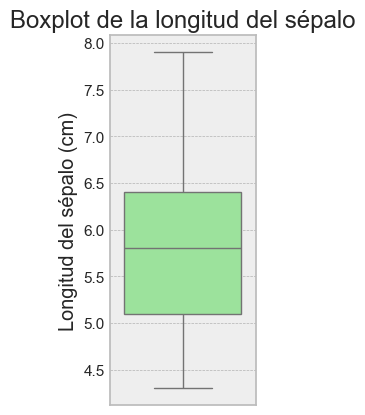

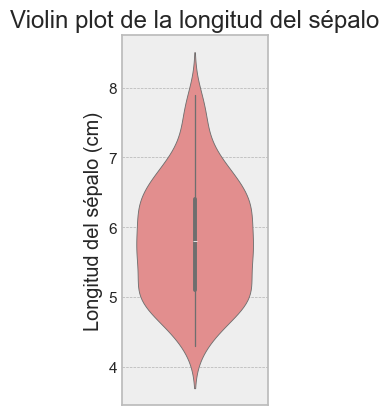

<Figure size 640x480 with 0 Axes>

In [235]:
### Longitud del sepalo
### Histograma de la longitud del sépalo
plt.subplot(1, 3, 1)
sns.histplot(df["sep_l (cm)"], kde=True, color="skyblue", bins=20)
plt.title("Distribución de la longitud del sépalo")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("count")
plt.show()
### boxplot de la longitud del sépalo
plt.subplot(1, 3, 2)
sns.boxplot(y=df["sep_l (cm)"], color="lightgreen")
plt.title("Boxplot de la longitud del sépalo")
plt.ylabel("Longitud del sépalo (cm)")
plt.show()
### violin plot de la longitud del sépalo
plt.subplot(1, 3, 3)
sns.violinplot(y=df["sep_l (cm)"], color="lightcoral")
plt.title("Violin plot de la longitud del sépalo")
plt.ylabel("Longitud del sépalo (cm)")
plt.show()
### muestra los gráficos
plt.tight_layout()
plt.show()

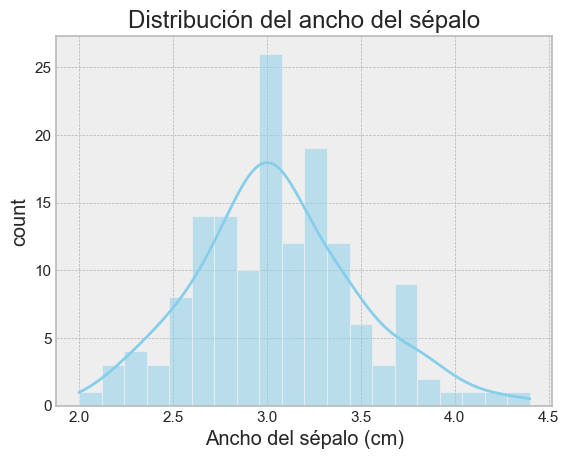

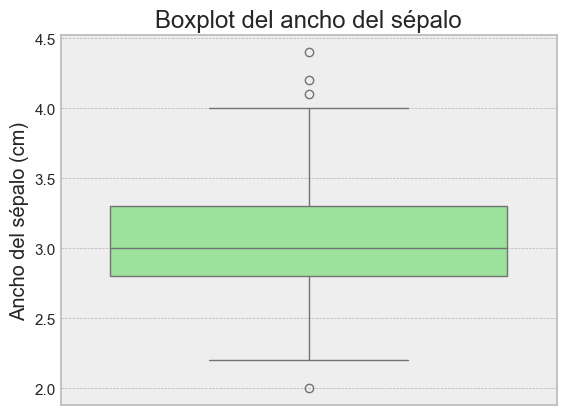

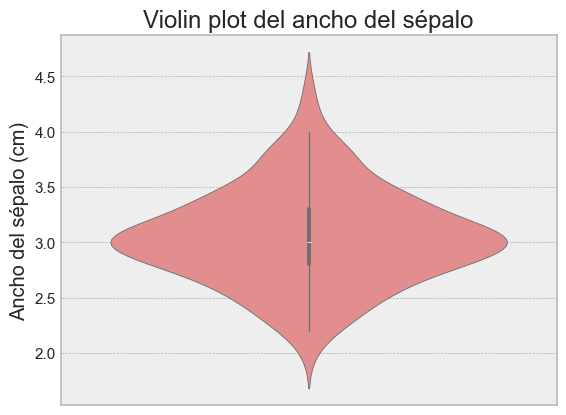

<Figure size 640x480 with 0 Axes>

In [236]:
### ancho del sepalo
### Histograma del ancho del sépalo
sns.histplot(df["sep_w (cm)"], kde=True, color="skyblue", bins=20)
plt.title("Distribución del ancho del sépalo")
plt.xlabel("Ancho del sépalo (cm)")
plt.ylabel("count")
plt.show()
### boxplot del ancho del sépalo
sns.boxplot(y=df["sep_w (cm)"], color="lightgreen")
plt.title("Boxplot del ancho del sépalo")
plt.ylabel("Ancho del sépalo (cm)")
plt.show()
### violin plot del ancho del sépalo
sns.violinplot(y=df["sep_w (cm)"], color="lightcoral")
plt.title("Violin plot del ancho del sépalo")
plt.ylabel("Ancho del sépalo (cm)")
plt.show()
### muestra los gráficos
plt.tight_layout()
plt.show()


In [3]:
### en el boxplot del ancho del sépalo observamos 4 outliers: 3 por arriba y 1 por abajo.

###
Analsis Multivariante

C:\Users\Surface\AppData\Local\Temp\ipykernel_15680\1852251105.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="especie", y="sep_l (cm)", data=df, palette="pastel", ax=axs[0,1])
C:\Users\Surface\AppData\Local\Temp\ipykernel_15680\1852251105.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="especie", y="sep_l (cm)", data=df, palette="pastel", ax=axs[1,0])


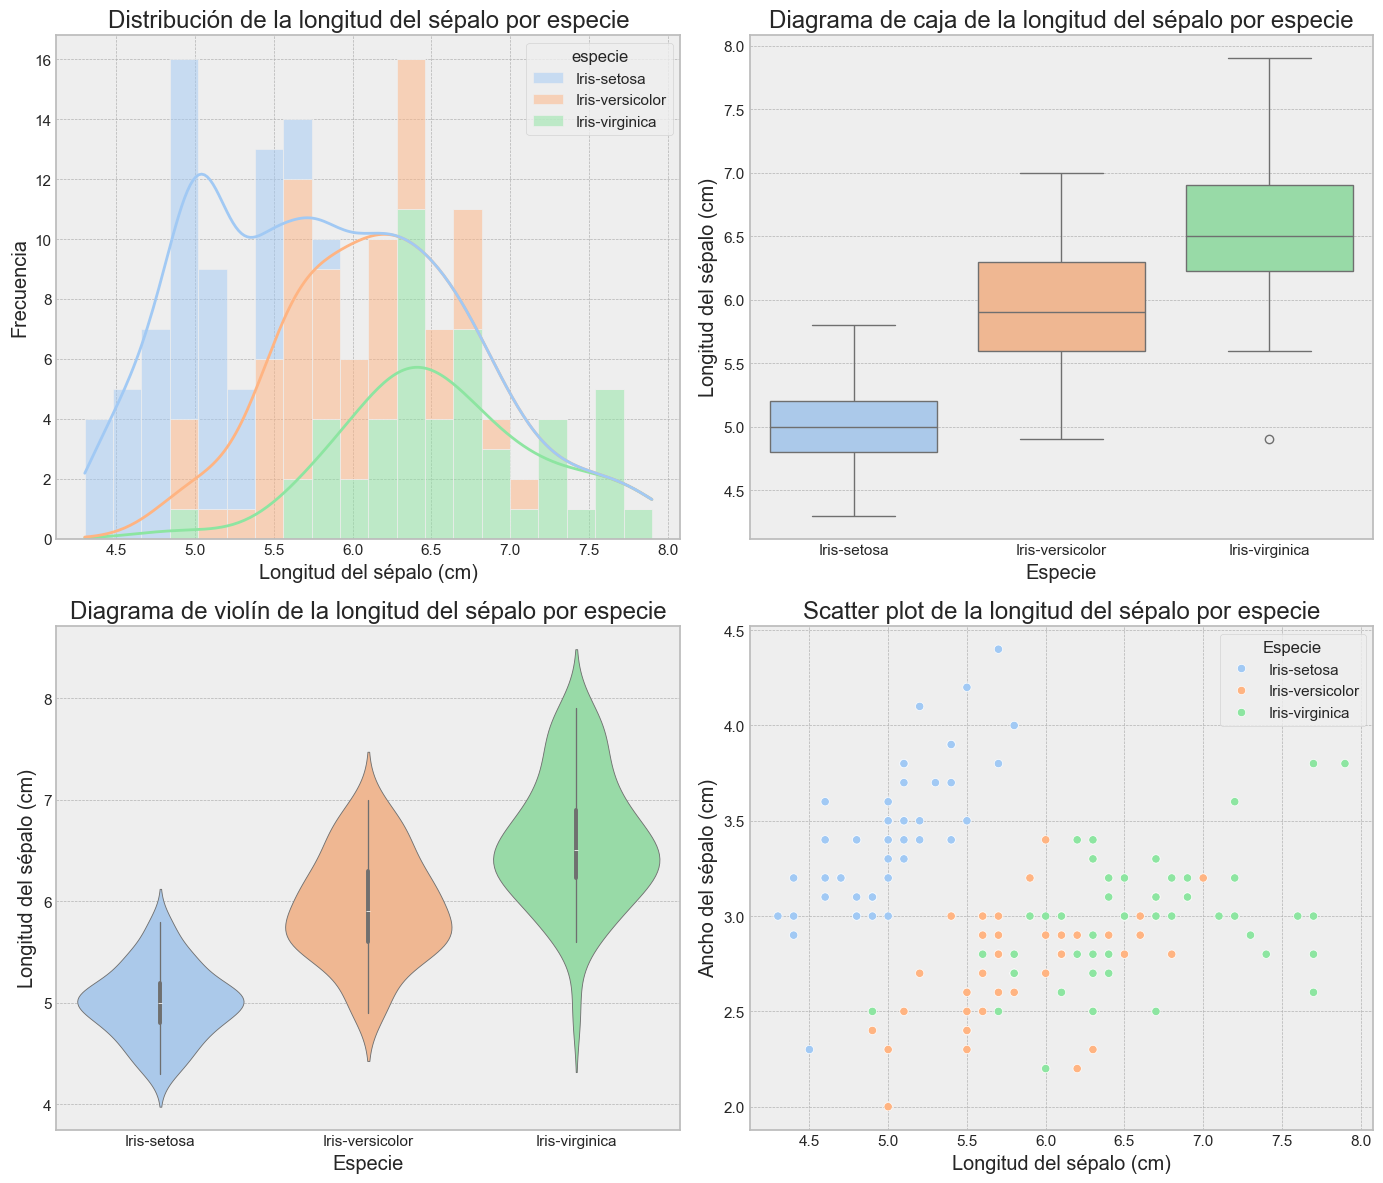

In [237]:
### Longitud entre sepalo y especie
fig,axs=plt.subplots(2,2,figsize=(14,12))
### Histograma de la longitud del sépalo por especie
sns.histplot(data=df, x="sep_l (cm)", hue="especie",multiple="stack", kde=True, palette="pastel",bins=20 , ax=axs[0,0])
axs[0,0].set_title("Distribución de la longitud del sépalo por especie")
axs[0,0].set_xlabel("Longitud del sépalo (cm)")
axs[0,0].set_ylabel("Frecuencia")
 ###Diagrama de caja de la longitud del sépalo por especie
sns.boxplot(x="especie", y="sep_l (cm)", data=df, palette="pastel", ax=axs[0,1])
axs[0,1].set_title("Diagrama de caja de la longitud del sépalo por especie")
axs[0,1].set_xlabel("Especie")
axs[0,1].set_ylabel("Longitud del sépalo (cm)")
###Diagrama de violín de la longitud del sépalo por especie
sns.violinplot(x="especie", y="sep_l (cm)", data=df, palette="pastel", ax=axs[1,0])
axs[1,0].set_title("Diagrama de violín de la longitud del sépalo por especie")
axs[1,0].set_xlabel("Especie")
axs[1,0].set_ylabel("Longitud del sépalo (cm)")
###Scatter plot de la longitud del sépalo por especie
sns.scatterplot(x="sep_l (cm)", y="sep_w (cm)", hue="especie", data=df, palette="pastel", ax=axs[1,1])
axs[1,1].set_title("Scatter plot de la longitud del sépalo por especie")
axs[1,1].set_xlabel("Longitud del sépalo (cm)")
axs[1,1].set_ylabel("Ancho del sépalo (cm)")
axs[1,1].legend(title="Especie")
###Ajuste de los gráficos
plt.tight_layout()
plt.show()

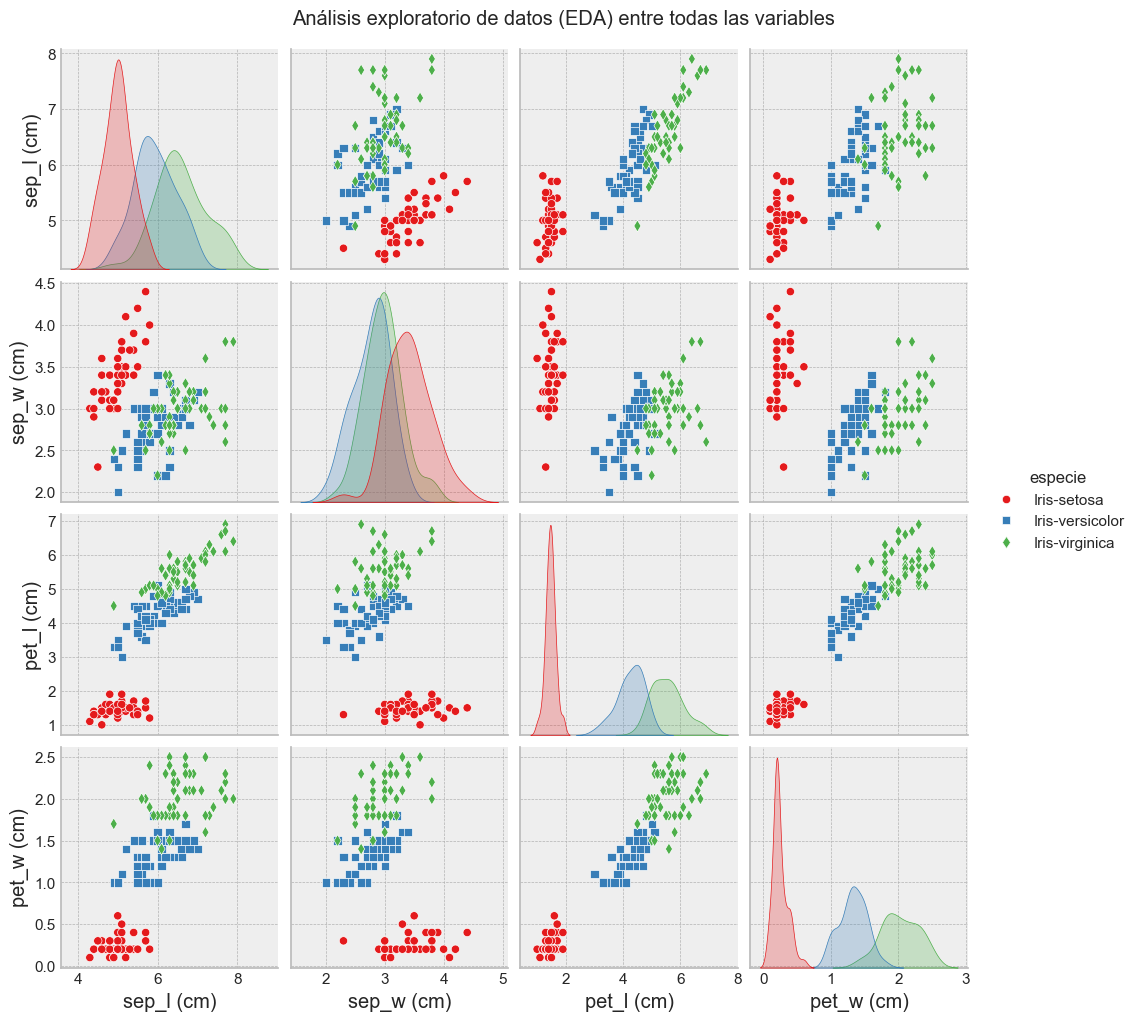

In [238]:
### Análisis exploratorio de datos (EDA) entre todas las variables
sns.pairplot(df, hue="especie", palette="Set1" , markers=["o", "s", "d"] , diag_kind="kde")
plt.suptitle("Análisis exploratorio de datos (EDA) entre todas las variables", y=1.02)
plt.show()

In [239]:
### Correlacion entre variables
df.corr(numeric_only=True)

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm)
sep_l (cm),1.000000,-0.109369,0.871754,0.817954
sep_w (cm),-0.109369,1.000000,-0.420516,-0.356544
pet_l (cm),0.871754,-0.420516,1.000000,0.962757
pet_w (cm),0.817954,-0.356544,0.962757,1.000000


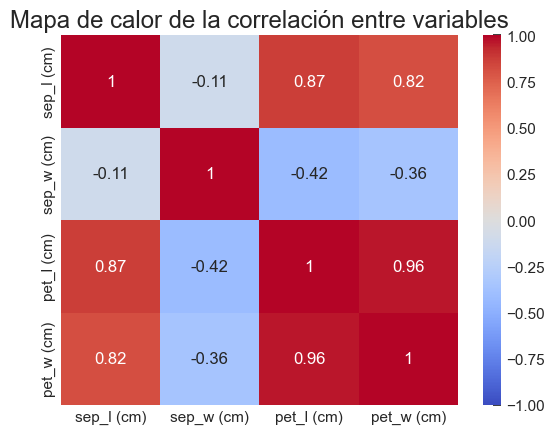

In [240]:
###Hacer un heatmap
plt.Figure(figsize=(8,6))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap= "coolwarm", vmin=-1, vmax=1)
plt.title("Mapa de calor de la correlación entre variables")
plt.show()


In [1]:
### Las variables estás muy relaxionadas entre sí, por lo que existe correlación entre ellas.

In [241]:
dummies= pd.get_dummies(df["especie"], prefix="especie").columns
df = df.join(pd.get_dummies(df["especie"], prefix="especie"))
df

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm),especie,especie_Iris-setosa,especie_Iris-versicolor,especie_Iris-virginica
0,5.1,3.5,1.4,0.2,Iris-setosa,True,False,False
1,4.9,3.0,1.4,0.2,Iris-setosa,True,False,False
2,4.7,3.2,1.3,0.2,Iris-setosa,True,False,False
3,4.6,3.1,1.5,0.2,Iris-setosa,True,False,False
4,5.0,3.6,1.4,0.2,Iris-setosa,True,False,False
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,False,False,True
146,6.3,2.5,5.0,1.9,Iris-virginica,False,False,True
147,6.5,3.0,5.2,2.0,Iris-virginica,False,False,True
148,6.2,3.4,5.4,2.3,Iris-virginica,False,False,True


In [242]:
df.drop(columns=["especie"], inplace=True)
df

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm),especie_Iris-setosa,especie_Iris-versicolor,especie_Iris-virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


In [243]:
scaler = MinMaxScaler()
numcol = df.select_dtypes(include=['float64', 'int64']).columns
df[numcol]=scaler.fit_transform(df[numcol])
###numcol= df.select_dtypes(include=["bool"]).columns###
###df[numcol]=df[numcol].astype(int)### para convertir booleanos a enteros
df

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm),especie_Iris-setosa,especie_Iris-versicolor,especie_Iris-virginica
0,0.222222,0.625000,0.067797,0.041667,True,False,False
1,0.166667,0.416667,0.067797,0.041667,True,False,False
2,0.111111,0.500000,0.050847,0.041667,True,False,False
3,0.083333,0.458333,0.084746,0.041667,True,False,False
4,0.194444,0.666667,0.067797,0.041667,True,False,False
...,...,...,...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667,False,False,True
146,0.555556,0.208333,0.677966,0.750000,False,False,True
147,0.611111,0.416667,0.711864,0.791667,False,False,True
148,0.527778,0.583333,0.745763,0.916667,False,False,True


In [244]:
df.corr(numeric_only=True).loc[:,["sep_l (cm)","sep_w (cm)","pet_l (cm)","pet_w (cm)"]]

,sep_l (cm),sep_w (cm),pet_l (cm),pet_w (cm)
sep_l (cm),1.000000,-0.109369,0.871754,0.817954
sep_w (cm),-0.109369,1.000000,-0.420516,-0.356544
pet_l (cm),0.871754,-0.420516,1.000000,0.962757
pet_w (cm),0.817954,-0.356544,0.962757,1.000000
especie_Iris-setosa,-0.717416,0.595601,-0.922688,-0.887510
especie_Iris-versicolor,0.079396,-0.464700,0.201587,0.118376
especie_Iris-virginica,0.638020,-0.130901,0.721102,0.769134


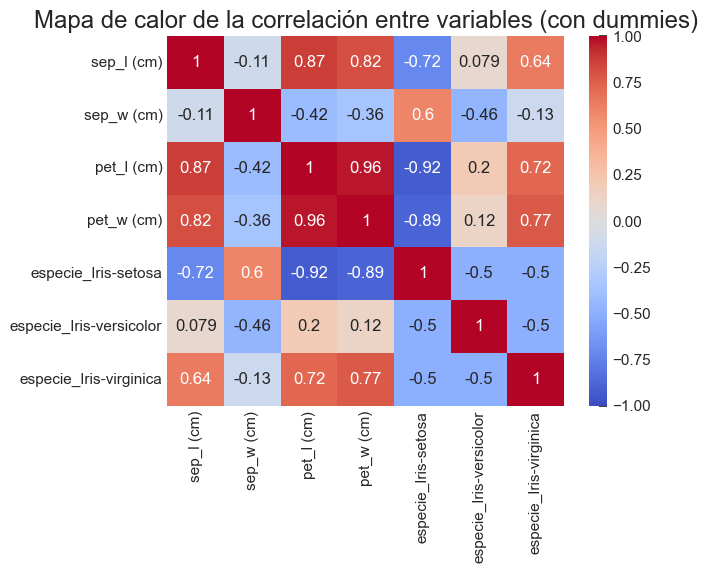

In [245]:
plt.Figure(figsize=(8,6))
correlation_matrix = pd.get_dummies(df, prefix="especie").corr()
sns.heatmap(correlation_matrix, annot=True, cmap= "coolwarm", vmin=-1, vmax=1)
plt.title("Mapa de calor de la correlación entre variables (con dummies)")
plt.show()

In [2]:
###El análisis confirma que las medidas de los pétalos son las variables más discriminantes para clasificar correctamente las especies de Iris, mientras que las de los sépalos tienen menor poder explicativo. Esto coincide con lo observado históricamente en este dataset y explica por qué los modelos de clasificación logran alta precisión cuando incluyen las variables de pétalos.

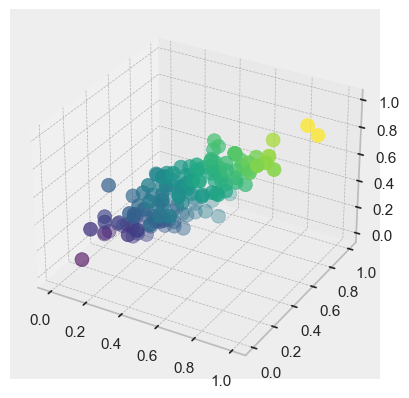

In [246]:
### relacion 3D entre variables
plt.Figure(figsize=(10,8))
ax = plt.axes(projection='3d')
ax.scatter3D(
	df['sep_l (cm)'],
	df['sep_w (cm)'],
	df['pet_l (cm)'],
	c=df[['sep_l (cm)', 'sep_w (cm)', 'pet_l (cm)']].mean(axis=1),	
	cmap='viridis',
	s=100
)
plt.show()

###
Creamos PCA

In [247]:
### PCA ###
features= df.select_dtypes(include=np.number)
pca3 = PCA(n_components=3)
pca3.fit(features)
features_reduced_3 = pca3.transform(features)
print (pca3.explained_variance_ratio_)

print (features_reduced_3)
pca3= pd.DataFrame(data=features_reduced_3, columns=['PC1', 'PC2', 'PC3'])
pca3

[0.84141901 0.11732474 0.03490564]
[[-6.30361249e-01  1.11556258e-01  1.69929115e-02]
 [-6.23546310e-01 -1.00313199e-01  4.71201236e-02]
 [-6.69792802e-01 -4.72200571e-02 -2.16477393e-02]
 [-6.54633051e-01 -9.87912747e-02 -2.52141464e-02]
 [-6.48263265e-01  1.37557689e-01 -1.68125515e-02]
 [-5.34057000e-01  2.93223042e-01 -2.67364715e-02]
 [-6.56395887e-01  1.49219390e-02 -9.36980789e-02]
 [-6.25643957e-01  6.10753191e-02  1.22695676e-02]
 [-6.76525845e-01 -1.96482315e-01 -3.81316446e-02]
 [-6.46137172e-01 -6.32422300e-02  5.97536915e-02]
 [-5.96654863e-01  2.20941913e-01  4.97532816e-02]
 [-6.38828681e-01  3.65958117e-02 -2.62592393e-02]
 [-6.62304799e-01 -1.11542611e-01  5.27164740e-02]
 [-7.52700136e-01 -1.66744846e-01 -4.99686959e-02]
 [-5.98993148e-01  3.84079343e-01  8.37661851e-02]
 [-5.49943265e-01  5.18967671e-01 -3.93346854e-02]
 [-5.75826838e-01  2.97584158e-01 -3.13642188e-02]
 [-6.03416352e-01  1.11091056e-01 -8.44631071e-03]
 [-5.19472697e-01  2.91076041e-01  7.21939575e-

,PC1,PC2,PC3
0,-0.630361,0.111556,0.016993
1,-0.623546,-0.100313,0.047120
2,-0.669793,-0.047220,-0.021648
3,-0.654633,-0.098791,-0.025214
4,-0.648263,0.137558,-0.016813
...,...,...,...
145,0.551755,0.058990,-0.085968
146,0.406278,-0.172227,0.003916
147,0.447293,0.036996,-0.049336
148,0.489218,0.149121,-0.238719


In [248]:
### cambiamos componentes a 2 ###
pca = PCA(n_components=2)
pca.fit(df.select_dtypes(include=np.number))
pca_data = pca.transform(df.select_dtypes(include=np.number))
print(pca.explained_variance_ratio_)
print(pca.components_)
print(pca_data)
pca_data.shape
pca_data_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_data_df.head(10)

[0.84141901 0.11732474]
[[ 0.4252893  -0.14612219  0.61610511  0.64667752]
 [ 0.42100611  0.90470509 -0.06432645 -0.01116485]]
[[-6.30361249e-01  1.11556258e-01]
 [-6.23546310e-01 -1.00313199e-01]
 [-6.69792802e-01 -4.72200571e-02]
 [-6.54633051e-01 -9.87912747e-02]
 [-6.48263265e-01  1.37557689e-01]
 [-5.34057000e-01  2.93223042e-01]
 [-6.56395887e-01  1.49219390e-02]
 [-6.25643957e-01  6.10753191e-02]
 [-6.76525845e-01 -1.96482315e-01]
 [-6.46137172e-01 -6.32422300e-02]
 [-5.96654863e-01  2.20941913e-01]
 [-6.38828681e-01  3.65958117e-02]
 [-6.62304799e-01 -1.11542611e-01]
 [-7.52700136e-01 -1.66744846e-01]
 [-5.98993148e-01  3.84079343e-01]
 [-5.49943265e-01  5.18967671e-01]
 [-5.75826838e-01  2.97584158e-01]
 [-6.03416352e-01  1.11091056e-01]
 [-5.19472697e-01  2.91076041e-01]
 [-6.11239166e-01  2.23088914e-01]
 [-5.57504671e-01  1.05673218e-01]
 [-5.78205845e-01  1.84927666e-01]
 [-7.37287470e-01  9.51403474e-02]
 [-5.06022332e-01  3.14977242e-02]
 [-6.07501302e-01  3.33249752e-02

,PC1,PC2
0,-0.630361,0.111556
1,-0.623546,-0.100313
2,-0.669793,-0.047220
3,-0.654633,-0.098791
4,-0.648263,0.137558
5,-0.534057,0.293223
6,-0.656396,0.014922
7,-0.625644,0.061075
8,-0.676526,-0.196482
9,-0.646137,-0.063242


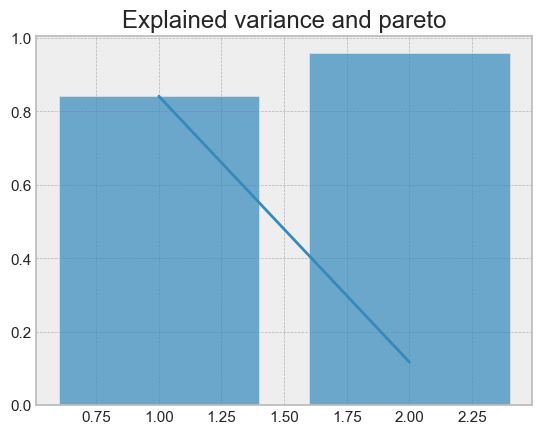

In [249]:
plt.plot(range(1,3),pca.explained_variance_ratio_)
plt.bar(range(1,3),np.cumsum(pca.explained_variance_ratio_), alpha=.7)
plt.title("Explained variance and pareto")
plt.show()

In [250]:
# Cargar el conjunto de datos MNIST-like
digits = load_digits()

# Acceder a los datos y las etiquetas
X = digits.data  # Datos de las imágenes
y = digits.target  # Etiquetas (dígitos)

print(X.shape, y.shape)


(1797, 64) (1797,)


In [251]:
feat_cols = [ 'pixel'+str(i) for i in range(X.shape[1]) ]

df = pd.DataFrame(X,columns=feat_cols)
df['y'] = y
df['label'] = df['y'].apply(lambda i: str(i))

X, y = None, None

print('Size of the dataframe: {}'.format(df.shape))
df.head()

Size of the dataframe: (1797, 66)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,y,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4,4


In [252]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 66 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pixel0   1797 non-null   float64
 1   pixel1   1797 non-null   float64
 2   pixel2   1797 non-null   float64
 3   pixel3   1797 non-null   float64
 4   pixel4   1797 non-null   float64
 5   pixel5   1797 non-null   float64
 6   pixel6   1797 non-null   float64
 7   pixel7   1797 non-null   float64
 8   pixel8   1797 non-null   float64
 9   pixel9   1797 non-null   float64
 10  pixel10  1797 non-null   float64
 11  pixel11  1797 non-null   float64
 12  pixel12  1797 non-null   float64
 13  pixel13  1797 non-null   float64
 14  pixel14  1797 non-null   float64
 15  pixel15  1797 non-null   float64
 16  pixel16  1797 non-null   float64
 17  pixel17  1797 non-null   float64
 18  pixel18  1797 non-null   float64
 19  pixel19  1797 non-null   float64
 20  pixel20  1797 non-null   float64
 21  pixel21  1797 

In [253]:
df.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,y
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [254]:
df.isnull().sum()

pixel0     0
pixel1     0
pixel2     0
pixel3     0
pixel4     0
          ..
pixel61    0
pixel62    0
pixel63    0
y          0
label      0
Length: 66, dtype: int64

In [255]:
df.corr()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,y,label
pixel0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel1,NaN,1.000000,0.556618,0.207814,-0.018761,0.060776,0.048388,-0.038927,0.032320,0.556372,...,-0.007905,0.855610,0.555727,0.147646,-0.102349,-0.029870,0.026547,-0.043889,-0.051834,-0.051834
pixel2,NaN,0.556618,1.000000,0.560180,-0.084235,0.043569,0.002841,-0.062278,0.022311,0.582259,...,-0.025837,0.515276,0.937623,0.499840,-0.134754,-0.041183,0.072599,0.082523,-0.011836,-0.011836
pixel3,NaN,0.207814,0.560180,1.000000,0.023938,-0.171377,-0.115732,-0.040139,0.035663,0.328344,...,-0.049085,0.175804,0.560326,0.767945,-0.065957,-0.054936,0.053437,0.081971,-0.011489,-0.011489
pixel4,NaN,-0.018761,-0.084235,0.023938,1.000000,0.507731,0.127764,0.010065,0.042065,0.051657,...,0.017352,-0.047223,-0.020176,-0.008867,-0.082125,-0.215809,-0.250699,-0.215349,0.100801,0.100801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel61,NaN,-0.029870,-0.041183,-0.054936,-0.215809,-0.268818,-0.304111,-0.141174,0.033409,0.071488,...,-0.003056,-0.043889,-0.091839,-0.094956,0.609515,1.000000,0.648328,0.261991,-0.079100,-0.079100
pixel62,NaN,0.026547,0.072599,0.053437,-0.250699,-0.267659,-0.178945,-0.063220,0.020689,0.111569,...,-0.011932,0.014557,0.035369,0.006849,0.243305,0.648328,1.000000,0.620428,-0.114007,-0.114007
pixel63,NaN,-0.043889,0.082523,0.081971,-0.215349,-0.167727,-0.080309,-0.024505,-0.005226,-0.001404,...,-0.004625,-0.047089,0.031193,0.099671,0.103015,0.261991,0.620428,1.000000,-0.181929,-0.181929
y,NaN,-0.051834,-0.011836,-0.011489,0.100801,0.193362,0.197343,0.101085,0.020813,-0.012439,...,-0.020518,-0.053950,0.006367,-0.019790,-0.196083,-0.079100,-0.114007,-0.181929,1.000000,1.000000


In [256]:
scaler = MinMaxScaler()
numcol = df.select_dtypes(include=['float64', 'int64']).columns
df[numcol]=scaler.fit_transform(df[numcol])
df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,y,label
0,0.0,0.0,0.3125,0.8125,0.5625,0.0625,0.0000,0.0,0.0,0.0000,...,0.0,0.000000,0.3750,0.8125,0.6250,0.0000,0.0000,0.0,0.000000,0
1,0.0,0.0,0.0000,0.7500,0.8125,0.3125,0.0000,0.0,0.0,0.0000,...,0.0,0.000000,0.0000,0.6875,1.0000,0.6250,0.0000,0.0,0.111111,1
2,0.0,0.0,0.0000,0.2500,0.9375,0.7500,0.0000,0.0,0.0,0.0000,...,0.0,0.000000,0.0000,0.1875,0.6875,1.0000,0.5625,0.0,0.222222,2
3,0.0,0.0,0.4375,0.9375,0.8125,0.0625,0.0000,0.0,0.0,0.5000,...,0.0,0.000000,0.4375,0.8125,0.8125,0.5625,0.0000,0.0,0.333333,3
4,0.0,0.0,0.0000,0.0625,0.6875,0.0000,0.0000,0.0,0.0,0.0000,...,0.0,0.000000,0.0000,0.1250,1.0000,0.2500,0.0000,0.0,0.444444,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,0.2500,0.6250,0.8125,0.3750,0.0000,0.0,0.0,0.0625,...,0.0,0.000000,0.1250,0.8750,0.9375,0.5625,0.0000,0.0,1.000000,9
1793,0.0,0.0,0.3750,1.0000,0.8125,0.6875,0.0625,0.0,0.0,0.0000,...,0.0,0.000000,0.3750,1.0000,0.8750,0.3750,0.0000,0.0,0.000000,0
1794,0.0,0.0,0.0625,0.6875,0.9375,0.0625,0.0000,0.0,0.0,0.0000,...,0.0,0.000000,0.1250,0.5625,0.8125,0.3750,0.0000,0.0,0.888889,8
1795,0.0,0.0,0.1250,0.6250,0.4375,0.0000,0.0000,0.0,0.0,0.0000,...,0.0,0.000000,0.3125,0.7500,1.0000,0.7500,0.0000,0.0,1.000000,9


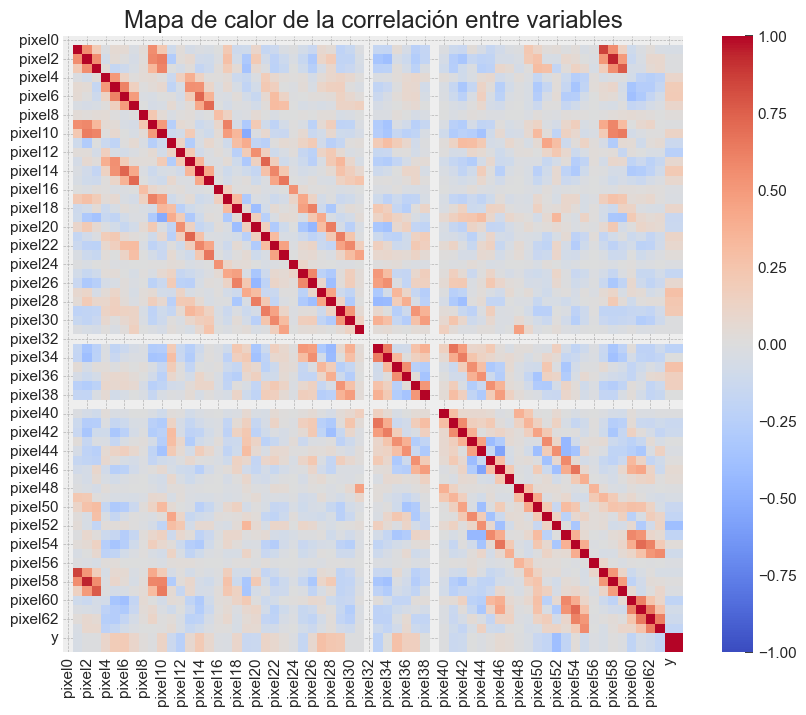

In [257]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False , vmin=-1, vmax=1)
plt.title("Mapa de calor de la correlación entre variables")
plt.show()

In [1]:
###Se observa una fuerte autocorrelación en la diagonal principal y la existencia de grupos de píxeles altamente correlacionados, lo que sugiere redundancia entre variables y justifica aplicar una reducción de dimensionalidad como PCA.

In [260]:
num_cols = df.select_dtypes(include=np.number).columns
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [266]:
pca = PCA(n_components=2)
pca.fit(df.select_dtypes(include=np.number))
pca_data = pca.transform(df.select_dtypes(include=np.number))
print (pca.explained_variance_ratio_)
print (pca.components_)
print (pca_data)
pca_data_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_data_df.head(10)



[0.22101832 0.14676607]
[[ 0.00000000e+00  7.58092024e-03  7.34227142e-02  1.06858755e-01
  -9.63670098e-02 -8.70249234e-02 -3.70766817e-02 -6.83759334e-03
   1.14846164e-03  1.48974536e-01  5.46869253e-02 -4.24895091e-03
   7.18723984e-03 -5.97799166e-02 -4.36935717e-01 -7.83407885e-03
   5.25654507e-04  8.44085545e-02 -7.24969409e-03 -1.14917754e-03
   4.94543569e-02 -5.26684347e-02 -2.57865557e-01 -4.99227856e-03
   9.51694998e-06 -5.46181134e-02 -5.09244953e-02  8.98507497e-03
   2.52836278e-02 -7.83487770e-02 -1.75160719e-01 -1.70825112e-03
   0.00000000e+00 -1.24158402e-01 -5.59140221e-02  2.42052327e-03
   1.29234302e-03 -6.65684025e-02 -5.77971460e-02  0.00000000e+00
  -1.15331587e-03 -1.85503977e-01 -1.87285771e-02  6.46048440e-03
  -4.04275353e-02 -4.70296249e-02  6.23298458e-02  2.61016864e-03
  -4.32230229e-04 -9.46243140e-04  5.72965269e-02  4.83021481e-02
  -3.63353571e-02  4.44846737e-02  1.93455798e-01  1.28907244e-02
  -1.07828554e-04  5.24278404e-03  6.01478008e-02  7

,PC1,PC2
0,-2.759849,0.601168
1,-0.078904,0.366758
2,1.944280,2.928685
3,1.098554,-0.860632
4,-1.752158,3.070812
5,0.449333,0.067175
6,1.243323,0.888120
7,-3.684586,-3.482366
8,0.181620,0.469947
9,0.409270,-0.092867


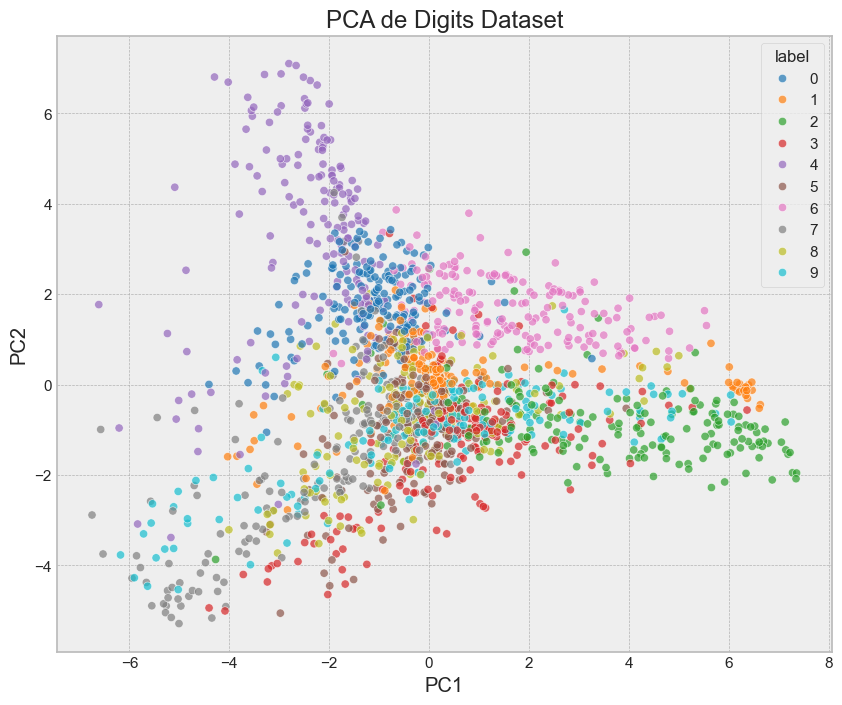

In [269]:
### Scatter plot de PCA ###
plt.figure(figsize=(10,8))
sns.scatterplot(x='PC1', y='PC2', hue=df['label'], palette='tab10', data=pca_data_df, legend='full', alpha=0.7)
plt.title('PCA de Digits Dataset')
plt.show()

In [2]:
###Se observa que los dígitos forman agrupaciones relativamente diferenciadas, lo que indica que las dos primeras componentes principales logran capturar buena parte de la variabilidad y separabilidad entre clases, aunque existen zonas de solapamiento entre algunos números visualmente similares.

In [271]:
### Analisis de t-sne
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(df.select_dtypes(include=np.number))
tsne_data_df = pd.DataFrame(data=tsne_data, columns=['Dim1', 'Dim2'])
tsne_data_df.head(10)


,Dim1,Dim2
0,-14.607470,46.819035
1,-13.436525,12.602101
2,24.679937,9.393408
3,29.390812,-23.253580
4,-33.580276,13.964590
5,17.682110,-14.427035
6,21.285904,20.427999
7,-32.046715,-16.638794
8,5.091202,0.573060
9,17.386667,-14.748425


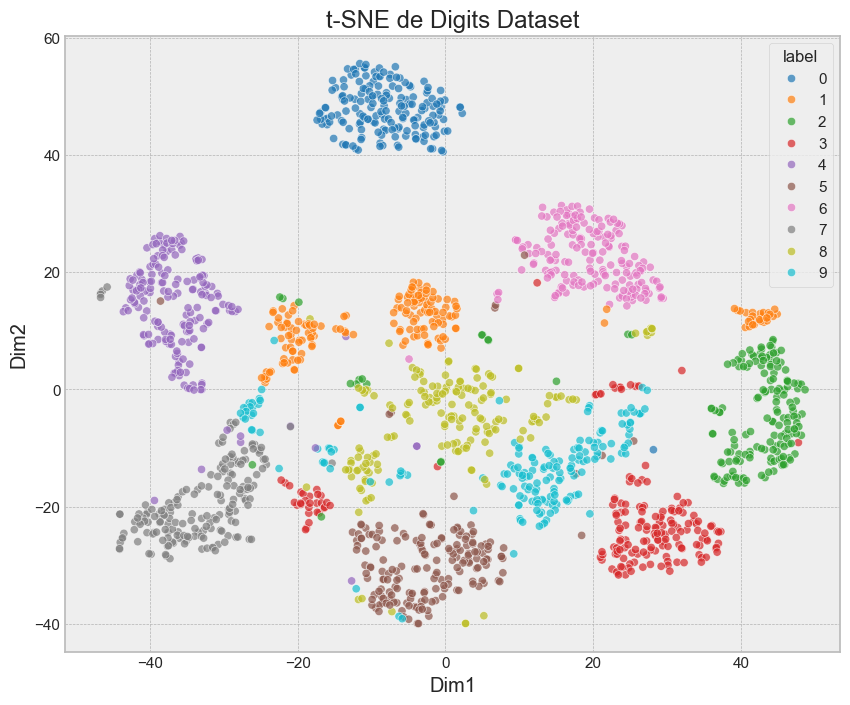

In [273]:
plt.figure(figsize=(10,8))
scatter = sns.scatterplot(x='Dim1', y='Dim2', hue=df['label'], palette='tab10', data=tsne_data_df, legend='full', alpha=0.7)
plt.title('t-SNE de Digits Dataset')
plt.show()

In [3]:
###El método logra una clara separación entre la mayoría de los dígitos, formando agrupaciones compactas y bien diferenciadas, lo que evidencia que el algoritmo preserva de forma efectiva la estructura local de los datos en el espacio reducido.

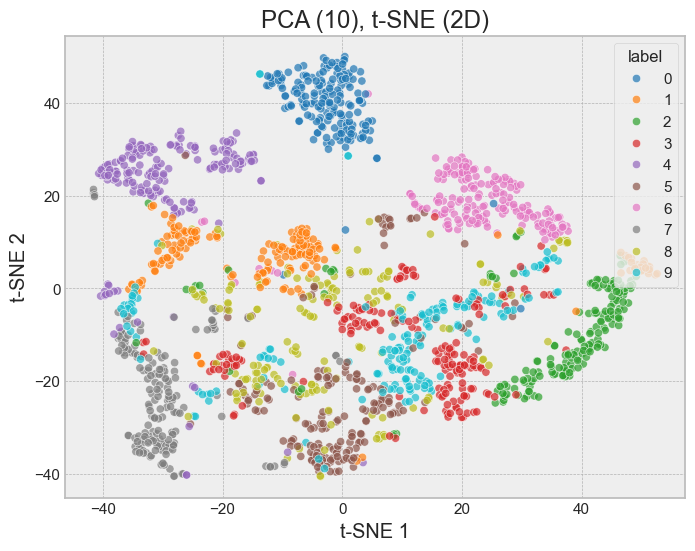

In [276]:
pca = PCA(n_components=10)  
X_pca = pca.fit_transform(df.select_dtypes(include=np.number))

### 4) t-SNE a 2D con semilla 0 
tsne = TSNE(n_components=2, random_state=0, init='pca', learning_rate='auto')
tsne_data = tsne.fit_transform(X_pca)


### 5) Scatter plot coloreado por la etiqueta
plt.figure(figsize=(8,6))
scatter = sns.scatterplot(x=tsne_data[:,0], y=tsne_data[:,1], hue=df['label'], palette='tab10', legend='full', alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('PCA (10), t-SNE (2D)')
plt.show()


In [4]:
###La combinación de ambas técnicas permite observar una clara separación entre grupos correspondientes a los distintos dígitos, con una organización más definida y compacta que en la proyección PCA original, lo que confirma la eficacia del t-SNE para representar relaciones locales en espacios reducidos.